# Pipeline 1 - Dates Matching

The first pipeline will automate the following actions.<br>
INPUTS: 
* AOI
* PERIOD
* OUTPUT FOLDER (output will be organized by AOI)

ACTIONS:
1. Open the AOI
2. Create the S2 dataframe with cloud cover for the AOI and dates
3. Create the SWOT dataframe with the possible mosaics
4. Match SWOT and S2 dates, ordered by cloud cover
5. Create output structure in the AOI folder (/ref_masks, /OPERA, /dataframes)



## Imports

In [1]:
%load_ext autoreload
%autoreload 2

from swot_toolkit.pipe1 import prepare_aoi_dataframes
from swot_toolkit.swot import auth_earthaccess


In [2]:
auth_earthaccess()

## Pipeline 1

In [3]:
AOI = "/data/swot/AOIs/Rio_Branco.kml"
DATE_RANGE = ("2024-01-01", "2025-09-30")
OUTPUT_DIR = "/data/swot/output/"

Output directory created at: /data/swot/output/Rio_Branco
Searching for Sentinel-2 scenes intersecting the AOI...
S2 tile not provided. Guessing the best tile...
Tile 20MNE has 5631010 null values.
Tile 20MPE has 4834296 null values.
Best tile is 20MPE.
Assessing clouds in Sentinel-2 scenes...


  0%|          | 0/275 [00:00<?, ?it/s]

Searching for OPERA satellite data intersecting the AOI...
Found 219 OPERA satellite overpasses intersecting the AOI.
Searching for SWOT Raster_100 data intersecting the AOI...
Creating SWOT mosaics...


  0%|          | 0/27 [00:00<?, ?it/s]

Saving dataframes to /data/swot/output/Rio_Branco/dfs...


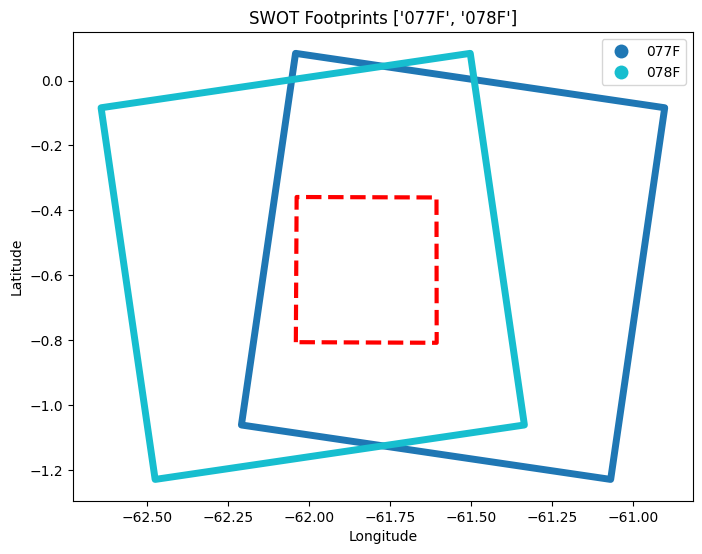

In [ ]:
output_dir = prepare_aoi_dataframes(AOI, DATE_RANGE, OUTPUT_DIR)

## Analyze results

In [21]:
import json

import pandas as pd

from swot_toolkit.kml import read_kml_geometry
from swot_toolkit.pipe1 import generate_s2_figs_from_mosaic

In [11]:
# Open the matches between S2 and SWOT
matches = pd.read_parquet(output_dir / "dfs/swot_s2_matches.parquet")
matches.sort_values("valid_pxls", ascending=False).iloc[:10]

,date,datetime,tile,valid_pxls,OPERA
swot_mosaic_date,,,,,
2024-04-03,2024-03-30,2024-03-30 14:27:11.024,20MPE,0.986592,S2A
2024-02-21,2024-02-19,2024-02-19 14:27:11.024,20MPE,0.985682,S2A
2024-08-27,2024-08-22,2024-08-22 14:27:09.024,20MPE,0.959455,S2B
2025-09-07,2025-09-11,2025-09-11 14:27:31.025,20MPE,0.935522,S2C
2025-04-14,2025-04-14,2025-04-14 14:28:11.025,20MPE,0.926655,S2C
2024-01-31,2024-01-30,2024-01-30 14:27:11.024,20MPE,0.904537,S2A
2024-02-21,2024-02-24,2024-02-24 14:27:09.024,20MPE,0.895677,S2B
2025-07-27,2025-07-23,2025-07-23 14:28:11.025,20MPE,0.835962,S2C
2024-09-17,2024-09-21,2024-09-21 14:27:09.024,20MPE,0.829485,S2B


### Choose a mosaic date to check the S2 items (figs generated in output dir)

In [ ]:
MOSAIC_DATE = "2024-08-27"

aoi = read_kml_geometry(AOI)[0]
s2_matches = generate_s2_figs_from_mosaic(
    MOSAIC_DATE,
    matches,
    aoi,
    output_dir,
)

s2_matches

Saving figure S2A_MSIL2A_20240830T143741_R096_T20MPE_20240830T204305_thumb.png...
Saving figure S2A_MSIL2A_20240827T142711_R053_T20MPE_20240827T203251_thumb.png...
Saving figure S2B_MSIL2A_20240825T143749_R096_T20MPE_20240825T165923_thumb.png...
Saving figure S2B_MSIL2A_20240822T142709_R053_T20MPE_20240822T212947_thumb.png...


,date,datetime,tile,valid_pxls,OPERA
swot_mosaic_date,,,,,
2024-08-27,2024-08-22,2024-08-22 14:27:09.024,20MPE,0.959455,S2B
2024-08-27,2024-08-25,2024-08-25 14:37:49.024,20MPE,0.052269,S2B
2024-08-27,2024-08-27,2024-08-27 14:27:11.024,20MPE,0.000000,S2A
2024-08-27,2024-08-30,2024-08-30 14:37:41.024,20MPE,0.185751,S2A


<Figure size 1000x1000 with 0 Axes>

### Selection of Dates

In [34]:
S2_IDS = {
    "2025-09-07": "S2C_MSIL2A_20250911T142731_R053_T20MPE_20250911T174714",
    "2024-08-27": "S2B_MSIL2A_20240822T142709_R053_T20MPE_20240822T212947",
}

# dump S2_IDS to the output root of directory as a json file
# First check if they have the correct length
for date, _id in S2_IDS.items():
    if len(_id) != 54:
        msg = f"ID {date} has length {len(_id)} instead of 54"
        raise ValueError(msg)
    if len(date) != 10:
        msg = f"Date {date} has length {len(date)} instead of 10"
        raise ValueError(msg)
    if len(_id.split("_")) != 6:
        msg = f"ID {_id} does not have 6 parts separated by '_'"
        raise ValueError(msg)

with open(output_dir / "S2_IDS.json", "w") as f:
    json.dump(S2_IDS, f, indent=4)
